# Laboratorio #6 - Aprendizaje por Refuerzo
* Paula Barillas - 22764
* Gerardo Pineda - 22880
* Mónica Salvatierra - 22249
* Bianca Calderón - 22272

- Link del repositorio: https://github.com/alee2602/LAB6-RL





**Contexto:**

Una empresa de robótica de asistencia médica está desarrollando un exoesqueleto para rehabilitación de movilidad en pacientes con lesiones de rodilla. El sistema de control debe aprender a asistir el movimiento
de la pierna del paciente de forma suave y eficiente, minimizando el esfuerzo del motor y maximizando la
fluidez del movimiento. Antes de trabajar con el hardware real, el equipo de ingeniería necesita validar si los métodos de gradiente de política son apropiados para este dominio de control continuo, usando entornos
de simulación estándar como proxy del problema real.
Su grupo ha sido contratado para implementar y comparar REINFORCE con línea base y un Actor-Critic simple,  analizar sus propiedades de convergencia, e investigar el estado del arte en control de exoesqueletos
con RL para producir un dictamen técnico fundamentado.

## **Task 1**

**1. El entorno de simulación que usarán es LunarLanderContinuous-v2 de Gymnasium, que tiene un
espacio de acción continuo de dos dimensiones representando la fuerza de dos propulsores.
Argumenten formalmente por qué Q-Learning tabular y DQN son inapropiados para este entorno. Su
argumento debe mencionar explícitamente el espacio de acción, el operador argmax, y la
representación de la política.**





El aprendizaje Q tabular requiere construir y actualizar una tabla con un valor $Q(s,a)$ para cada combinación de estado y acción, lo cual solo es viable cuando el espacio de acciones es finito y de tamaño manejable. En LunarLanderContinuous-v2 el espacio de acción es continuo y bidimensional, ya que cada componente representa la fuerza aplicada por uno de los dos propulsores dentro de un rango real. Esto implica que existen infinitas acciones posibles para cada estado, de modo que una tabla Q no puede representarlas ni actualizarse de forma completa. Incluso si se discretizara el espacio de acción para forzarlo a ser tabular, la dimensionalidad crece de forma combinatoria con el número de divisiones elegidas por cada dimensión, lo que vuelve la representación impráctica y degrada la resolución del control, algo particularmente grave en un dominio donde se busca un movimiento suave y preciso.

DQN resuelve el problema de representar estados de alta dimensión mediante una red neuronal, pero conserva la misma limitación estructural que Q-Learning tabular en cuanto a la selección de acciones. Tanto para elegir la acción a ejecutar como para calcular el objetivo de entrenamiento mediante bootstrapping, DQN necesita evaluar

$$\arg\max_{a} Q(s,a)$$

Ese operador argmax asume que se puede enumerar o resolver eficientemente sobre un conjunto finito de acciones. En un espacio continuo no existe forma cerrada para resolver ese argmax, y aproximarlo numéricamente dentro del ciclo de control resulta costoso e impreciso, y no es lo que implementa la arquitectura estándar de DQN.

Finalmente, ambos métodos derivan la política de forma implícita y determinista a partir de Q, es decir

$$\pi(s) = \arg\max_{a} Q(s,a)$$

Esa representación no permite expresar una salida continua y graduada como la fuerza de dos propulsores, ni políticas estocásticas suaves útiles para explorar un espacio continuo. Por estas tres razones (espacio de acción continuo e infinito, intratabilidad del operador argmax, y una representación de política implícita y discreta) tanto Q-Learning tabular como DQN resultan inapropiados para este entorno.

**2. Para LunarLanderContinuous-v2, la política se parametrizará como una distribución Gaussiana
𝜋𝜃(𝑎 ∣ 𝑠) = 𝒩(𝜇𝜃, (𝑠)𝜎2𝐼) donde 𝜇𝜃(𝑠) es la salida de una red neuronal. Expliquen cómo se calcula ∇𝜃 ln 𝜋𝜃 (𝐴𝑡 ∣ 𝑆𝑡) para esta parametrización específica. Desarrollen la expresión analítica del gradiente del logaritmo de la densidad Gaussiana respecto a 𝜃, identificando qué parte depende de 𝜃 y qué parte no.**



La política se define como

$$\pi_\theta(a \mid s) = \mathcal{N}(\mu_\theta(s), \sigma^2 I)$$

una Gaussiana multivariante con media dependiente del estado a través de la red neuronal y varianza $\sigma^2 I$, donde $\sigma$ es un parámetro aprendible compartido entre las dimensiones de acción.

La densidad, para una acción de dimensión $d$, es

$$\pi_\theta(a \mid s) = \frac{1}{(2\pi)^{d/2}\sigma^d} \exp\left(-\frac{\lVert a - \mu_\theta(s) \rVert^2}{2\sigma^2}\right)$$

Tomando el logaritmo natural,

$$\ln \pi_\theta(a \mid s) = -\frac{d}{2}\ln(2\pi) - d\ln\sigma - \frac{\lVert a - \mu_\theta(s) \rVert^2}{2\sigma^2}$$

Para obtener $\nabla_\theta \ln \pi_\theta(A_t \mid S_t)$ se deriva esta expresión respecto a los parámetros $\theta$ de la red que produce $\mu_\theta(s)$. Los dos primeros términos, $-\frac{d}{2}\ln(2\pi)$ y $-d\ln\sigma$, no dependen de los parámetros de la red de la media, ya que solo dependen de $\sigma$ y de la constante $d$, por lo que su gradiente respecto a esos parámetros es cero. El único término que depende de $\theta$ es el tercero, y aplicando la regla de la cadena se obtiene

$$\nabla_\theta \ln \pi_\theta(A_t \mid S_t) = \frac{1}{\sigma^2}\left(A_t - \mu_\theta(S_t)\right) \cdot \nabla_\theta \mu_\theta(S_t)$$

Aquí $\nabla_\theta \mu_\theta(S_t)$ es el jacobiano de la salida de la red respecto a sus parámetros, calculado automáticamente por PyTorch mediante autodiferenciación. Este gradiente apunta en la dirección que ajusta los parámetros para que $\mu_\theta(S_t)$ se acerque a la acción efectivamente tomada $A_t$, y su magnitud está escalada por el error de predicción $(A_t - \mu_\theta(S_t))$ y por $1/\sigma^2$. Si $\sigma$ también se trata como parámetro aprendible, se calcula además su propio gradiente

$$\frac{\partial \ln \pi_\theta}{\partial \sigma} = -\frac{d}{\sigma} + \frac{\lVert A_t - \mu_\theta(S_t) \rVert^2}{\sigma^3}$$

que aumenta $\sigma$ cuando el error entre la acción tomada y la media predicha es sistemáticamente grande, y lo reduce en caso contrario, regulando así la exploración.

**3. Comparen formalmente REINFORCE con línea base y Actor-Critic en términos de sesgo y varianza del estimador del gradiente. Para cada algoritmo identifiquen: qué usa como estimador de la ventaja 𝐴̂ 𝑡, qué componente introduce sesgo, y qué componente introduce varianza. Predigan cuál algoritmo
esperan que converja más rápido en LunarLanderContinuous-v2 y justifiquen esa predicción.**



REINFORCE con línea base usa como estimador de la ventaja $\hat{A}_t$ la diferencia

$$\hat{A}_t = G_t - b(S_t)$$

donde $G_t$ es el retorno Monte Carlo obtenido sumando las recompensas reales observadas desde el paso $t$ hasta el final del episodio, y $b(S_t)$ es una red separada entrenada para aproximar $V^\pi(S_t)$. Este estimador es insesgado, porque $G_t$ es una muestra directa del retorno verdadero y la línea base no introduce sesgo, dado que su contribución esperada al gradiente es cero al no depender de la acción tomada. El costo de este estimador es una varianza alta, ya que $G_t$ acumula la aleatoriedad de todas las recompensas y transiciones futuras del episodio completo, lo cual se agrava en episodios largos como los de LunarLanderContinuous-v2.

Actor-Critic reemplaza $G_t$ por el error TD de un paso,

$$\delta_t = R_{t+1} + \gamma \hat{V}_w(S_{t+1}) - \hat{V}_w(S_t)$$

que actúa como estimador de la ventaja. Este estimador introduce sesgo porque depende de $\hat{V}_w$, una aproximación aprendida e imperfecta, sobre todo en las primeras etapas del entrenamiento cuando el Critic aún no ha convergido, ya que el bootstrapping propaga ese error de aproximación hacia la actualización del Actor. A cambio, la varianza se reduce considerablemente porque $\delta_t$ depende solo de una recompensa y una transición, no de la trayectoria completa.

Se espera que Actor-Critic converja más rápido en LunarLanderContinuous-v2. Los episodios de este entorno pueden extenderse varios cientos de pasos con dinámica física ruidosa, lo que hace que los retornos Monte Carlo de REINFORCE tengan varianza muy alta y que las actualizaciones, al ocurrir solo una vez por episodio completo, sean poco frecuentes. Actor-Critic, al actualizar en cada paso con un estimador de menor varianza, aprovecha mejor cada muestra de interacción y suaviza la optimización, lo cual típicamente se traduce en convergencia más rápida y estable, a costa de tolerar cierto sesgo inicial mientras el Critic mejora.

**4. El entorno de exoesqueleto real tiene una restricción que LunarLanderContinuous-v2 no tiene:
las acciones deben ser suaves en el tiempo para no causar movimientos bruscos que dañen al
paciente. Argumenten cómo modificarían la función de recompensa y la parametrización de la
política para incorporar esa restricción. ¿Cambiaría eso la elección entre REINFORCE y Actor-Critic?**



Para incorporar la restricción de suavidad se puede modificar la función de recompensa añadiendo un término de penalización proporcional al cambio entre acciones consecutivas, por ejemplo

$$r'_t = r_t - \lambda \lVert a_t - a_{t-1} \rVert^2$$

de forma que el agente sea penalizado cuando ejecuta variaciones bruscas en la fuerza aplicada al motor. Esta penalización puede extenderse a la segunda diferencia, es decir a la aceleración de la acción, si se busca limitar también cambios abruptos en la tasa de variación y no solo en la variación misma.

En cuanto a la parametrización de la política, el esquema actual depende únicamente del estado actual y no tiene memoria de la acción anterior, lo cual dificulta imponer suavidad de forma explícita. Una modificación razonable es aumentar la entrada de la red con la acción previa, de modo que $\mu_\theta$ dependa del par $(S_t, a_{t-1})$, permitiendo que la red module su salida en función de lo ya ejecutado. Otra alternativa es parametrizar la salida como un incremento acotado respecto a la acción anterior,

$$a_t = a_{t-1} + \Delta_\theta(S_t)$$

limitando explícitamente cuánto puede cambiar la acción en un paso. También es razonable introducir una arquitectura recurrente, como LSTM o GRU, que dé memoria temporal a la política, y sustituir el ruido de exploración Gaussiano independiente por un proceso de ruido correlacionado en el tiempo, como un proceso de Ornstein-Uhlenbeck, para que la exploración misma sea más suave.

Estas modificaciones no alteran la validez del teorema de gradiente de política ni el mecanismo básico de optimización, por lo que en principio tanto REINFORCE como Actor-Critic siguen siendo aplicables. Sin embargo, sí refuerzan la preferencia por Actor-Critic. Al convertir la recompensa en una señal densa que se entrega en cada paso, ya que el término de suavidad se evalúa en cada transición y no solo al final del episodio, el aprendizaje por diferencias temporales que usa Actor-Critic puede aprovechar esa señal inmediata con mayor eficiencia que un estimador Monte Carlo que solo se actualiza al cierre del episodio. Además, la menor varianza de Actor-Critic resulta especialmente valiosa en un dominio de seguridad como la rehabilitación médica, donde actualizaciones erráticas de alta varianza son más difíciles de tolerar que un sesgo moderado y controlable proveniente de un Critic bien entrenado.


## **Task 2**

In [2]:
#!pip install "gymnasium[box2d]" torch matplotlib numpy


In [3]:
import math
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
from matplotlib import animation
from IPython.display import HTML, display
import matplotlib.pyplot as plt

DEVICE = torch.device("cpu")   
SEED = 42                     

In [4]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


print("torch:", torch.__version__)
print("gymnasium:", gym.__version__)
print("numpy:", np.__version__)

torch: 2.7.1+cpu
gymnasium: 1.3.0
numpy: 2.4.4


In [5]:
ENV_IDS = ["LunarLanderContinuous-v2", "LunarLanderContinuous-v3"]

def make_env(render_mode=None):
    last_err = None
    for env_id in ENV_IDS:
        try:
            return gym.make(env_id, render_mode=render_mode), env_id
        except Exception as e:
            last_err = e
    try:
        env = gym.make("LunarLander-v3", continuous=True, render_mode=render_mode)
        return env, "LunarLander-v3 (continuous=True)"
    except Exception as e:
        raise RuntimeError(
            "No se pudo crear el entorno. Instala:  pip install 'gymnasium[box2d]'\n"
            f"Último error: {last_err} / {e}"
        )


_env, ENV_ID = make_env()
OBS_DIM = _env.observation_space.shape[0]
ACT_DIM = _env.action_space.shape[0]
ACT_LOW = _env.action_space.low
ACT_HIGH = _env.action_space.high
_env.close()

print(f"Entorno: {ENV_ID}")
print(f"dim(estado) = {OBS_DIM} | dim(accion) = {ACT_DIM} | rango = [{ACT_LOW}, {ACT_HIGH}]")

c:\Users\rebe1\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment LunarLanderContinuous-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


Entorno: LunarLanderContinuous-v3
dim(estado) = 8 | dim(accion) = 2 | rango = [[-1. -1.], [1. 1.]]


In [6]:
def mlp_body(obs_dim, hidden=64):
    return nn.Sequential(
        nn.Linear(obs_dim, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
    )


class GaussianPolicy(nn.Module):

    def __init__(self, obs_dim, act_dim, hidden=64, init_std=0.5):
        super().__init__()
        self.body = mlp_body(obs_dim, hidden)
        self.mu_head = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.full((act_dim,), math.log(init_std)))

    def forward(self, obs):
        mu = torch.tanh(self.mu_head(self.body(obs)))   # tanh
        std = self.log_std.exp().expand_as(mu)
        return mu, std

    def dist(self, obs):
        mu, std = self(obs)
        return torch.distributions.Normal(mu, std)


class ValueNetwork(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.body = mlp_body(obs_dim, hidden)
        self.v_head = nn.Linear(hidden, 1)

    def forward(self, obs):
        return self.v_head(self.body(obs)).squeeze(-1)


class ActorCriticNet(nn.Module):
    """Actor-Critic: cuerpo COMPARTIDO + cabeza mu (tanh) + cabeza escalar V_w(s)."""

    def __init__(self, obs_dim, act_dim, hidden=64, init_std=0.5):
        super().__init__()
        self.body = mlp_body(obs_dim, hidden)
        self.mu_head = nn.Linear(hidden, act_dim)
        self.value_head = nn.Linear(hidden, 1)
        self.log_std = nn.Parameter(torch.full((act_dim,), math.log(init_std)))

    def forward(self, obs):
        h = self.body(obs)
        mu = torch.tanh(self.mu_head(h))
        std = self.log_std.exp().expand_as(mu)
        value = self.value_head(h).squeeze(-1)
        return mu, std, value

    def dist_and_value(self, obs):
        mu, std, value = self(obs)
        return torch.distributions.Normal(mu, std), value

    def value_only(self, obs):
        return self.value_head(self.body(obs)).squeeze(-1)

    def actor_parameters(self):
        return [p for n, p in self.named_parameters() if not n.startswith("value_head")]


_p = GaussianPolicy(OBS_DIM, ACT_DIM)
print("sigma inicial:", _p.log_std.exp().detach().numpy())
print(_p)

sigma inicial: [0.5 0.5]
GaussianPolicy(
  (body): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (mu_head): Linear(in_features=64, out_features=2, bias=True)
)


In [7]:
def discounted_returns(rewards, gamma):
    out = np.empty(len(rewards), dtype=np.float32)
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        out[t] = running
    return torch.as_tensor(out, dtype=torch.float32, device=DEVICE)


def global_grad_norm(params):
    total = 0.0
    for p in params:
        if p.grad is not None:
            total += p.grad.detach().pow(2).sum().item()
    return math.sqrt(total)


def grad_norm_from_grads(grads):
    total = 0.0
    for g in grads:
        if g is not None:
            total += g.detach().pow(2).sum().item()
    return math.sqrt(total)


def moving_average(x, window=20):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < window:
        return np.arange(len(x)), x.copy()
    c = np.cumsum(np.insert(x, 0, 0.0))
    ma = (c[window:] - c[:-window]) / window
    return np.arange(window - 1, len(x)), ma

In [8]:
def train_reinforce(num_episodes=1000, gamma=0.99, lr_actor=1e-3, lr_baseline=1e-3,
                    max_steps=1000, normalize_adv=True, grad_clip=0.5,
                    seed=SEED, log_every=50):
    set_seed(seed)
    env, _ = make_env()

    actor = GaussianPolicy(OBS_DIM, ACT_DIM).to(DEVICE)
    baseline = ValueNetwork(OBS_DIM).to(DEVICE)
    opt_actor = optim.Adam(actor.parameters(), lr=lr_actor)
    opt_base = optim.Adam(baseline.parameters(), lr=lr_baseline)

    hist = {"reward": [], "grad_norm": [], "entropy": [], "length": [], "loss_v": []}
    t0 = time.time()

    for ep in range(num_episodes):
        if ep == 0:
            obs, _ = env.reset(seed=seed)
            env.action_space.seed(seed)
        else:
            obs, _ = env.reset()

        states, actions, rewards = [], [], []

        for _ in range(max_steps):
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
            with torch.no_grad():
                action = actor.dist(obs_t).sample()  
            a_np = action.cpu().numpy()
            next_obs, r, terminated, truncated, _ = env.step(np.clip(a_np, ACT_LOW, ACT_HIGH))

            states.append(obs)
            actions.append(a_np)
            rewards.append(r)
            obs = next_obs
            if terminated or truncated:
                break
        states_t = torch.as_tensor(np.array(states), dtype=torch.float32, device=DEVICE)
        actions_t = torch.as_tensor(np.array(actions), dtype=torch.float32, device=DEVICE)
        returns = discounted_returns(rewards, gamma)
        values = baseline(states_t)
        adv = returns - values.detach()
        if normalize_adv and len(adv) > 1:
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        dist = actor.dist(states_t)
        logp = dist.log_prob(actions_t).sum(-1)  # log pi(a|s)
        entropy = dist.entropy().sum(-1).mean()

        actor_loss = -(logp * adv).mean()
        opt_actor.zero_grad(set_to_none=True)
        actor_loss.backward()
        gnorm = global_grad_norm(actor.parameters())        # ||grad_theta L|| 
        nn.utils.clip_grad_norm_(actor.parameters(), grad_clip)
        opt_actor.step()

        baseline_loss = F.mse_loss(values, returns)         # pérdida cuadrática
        opt_base.zero_grad(set_to_none=True)
        baseline_loss.backward()
        nn.utils.clip_grad_norm_(baseline.parameters(), grad_clip)
        opt_base.step()

        hist["reward"].append(float(np.sum(rewards)))
        hist["grad_norm"].append(gnorm)
        hist["entropy"].append(entropy.item())
        hist["length"].append(len(rewards))
        hist["loss_v"].append(baseline_loss.item())

        if (ep + 1) % log_every == 0:
            last = np.mean(hist["reward"][-log_every:])
            print(f"[REINFORCE] ep {ep+1:4d}/{num_episodes} | R(prom {log_every}) = {last:8.2f} "
                  f"| ||grad|| = {gnorm:6.3f} | S[pi] = {entropy.item():5.3f} "
                  f"| sigma = {actor.log_std.exp().detach().numpy().round(3)} "
                  f"| {time.time()-t0:5.1f}s")

    env.close()
    return actor, baseline, hist

In [9]:
def train_actor_critic(num_episodes=1000, gamma=0.99, lr=7e-4, value_coef=0.5,
                       ent_coef=0.0, max_steps=1000, normalize_adv=True, grad_clip=0.5,
                       seed=SEED, log_every=50):
    set_seed(seed)
    env, _ = make_env()

    net = ActorCriticNet(OBS_DIM, ACT_DIM).to(DEVICE)
    opt = optim.Adam(net.parameters(), lr=lr)
    actor_params = net.actor_parameters()

    hist = {"reward": [], "grad_norm": [], "entropy": [], "length": [], "loss_v": []}
    t0 = time.time()

    for ep in range(num_episodes):
        if ep == 0:
            obs, _ = env.reset(seed=seed)
            env.action_space.seed(seed)
        else:
            obs, _ = env.reset()

        states, actions, rewards, next_states, terminals = [], [], [], [], []
        for _ in range(max_steps):
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
            with torch.no_grad():
                mu, std, _ = net(obs_t)
                action = torch.distributions.Normal(mu, std).sample()
            a_np = action.cpu().numpy()
            next_obs, r, terminated, truncated, _ = env.step(np.clip(a_np, ACT_LOW, ACT_HIGH))

            states.append(obs)
            actions.append(a_np)
            rewards.append(r)
            next_states.append(next_obs)
            terminals.append(float(terminated))  
            obs = next_obs
            if terminated or truncated:
                break

        states_t = torch.as_tensor(np.array(states), dtype=torch.float32, device=DEVICE)
        actions_t = torch.as_tensor(np.array(actions), dtype=torch.float32, device=DEVICE)
        next_states_t = torch.as_tensor(np.array(next_states), dtype=torch.float32, device=DEVICE)
        rewards_t = torch.as_tensor(np.array(rewards), dtype=torch.float32, device=DEVICE)
        term_t = torch.as_tensor(np.array(terminals), dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            next_values = net.value_only(next_states_t)
            targets = rewards_t + gamma * next_values * (1.0 - term_t)

        dist, values = net.dist_and_value(states_t)
        logp = dist.log_prob(actions_t).sum(-1)
        entropy = dist.entropy().sum(-1).mean()

        adv = targets - values.detach()
        if normalize_adv and len(adv) > 1:
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        actor_loss = -(logp * adv).mean() - ent_coef * entropy
        critic_loss = F.mse_loss(values, targets)

        grads = torch.autograd.grad(actor_loss, actor_params, retain_graph=True,
                                    allow_unused=True)
        gnorm = grad_norm_from_grads(grads)

        loss = actor_loss + value_coef * critic_loss
        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), grad_clip)
        opt.step()

        hist["reward"].append(float(np.sum(rewards)))
        hist["grad_norm"].append(gnorm)
        hist["entropy"].append(entropy.item())
        hist["length"].append(len(rewards))
        hist["loss_v"].append(critic_loss.item())

        if (ep + 1) % log_every == 0:
            last = np.mean(hist["reward"][-log_every:])
            print(f"[ActorCritic] ep {ep+1:4d}/{num_episodes} | R(prom {log_every}) = {last:8.2f} "
                  f"| ||grad|| = {gnorm:6.3f} | S[pi] = {entropy.item():5.3f} "
                  f"| sigma = {net.log_std.exp().detach().numpy().round(3)} "
                  f"| {time.time()-t0:5.1f}s")

    env.close()
    return net, hist

In [10]:
NUM_EPISODES = 1000

print("=" * 70)
actor_r, baseline_r, hist_reinforce = train_reinforce(num_episodes=NUM_EPISODES, seed=SEED)
print("=" * 70)
ac_net, hist_ac = train_actor_critic(num_episodes=NUM_EPISODES, seed=SEED)
print("=" * 70)

for name, h in [("REINFORCE+baseline", hist_reinforce), ("Actor-Critic", hist_ac)]:
    print(f"{name:20s} | R medio (últimos 100) = {np.mean(h['reward'][-100:]):8.2f} "
          f"| R máx = {np.max(h['reward']):8.2f} "
          f"| S[pi] final = {h['entropy'][-1]:5.3f}")

[REINFORCE] ep   50/1000 | R(prom 50) =  -223.24 | ||grad|| =  0.473 | S[pi] = 1.470 | sigma = [0.503 0.506] |   7.8s
[REINFORCE] ep  100/1000 | R(prom 50) =  -131.37 | ||grad|| =  0.348 | S[pi] = 1.471 | sigma = [0.502 0.508] |  13.6s
[REINFORCE] ep  150/1000 | R(prom 50) =  -104.60 | ||grad|| =  0.203 | S[pi] = 1.468 | sigma = [0.502 0.506] |  22.3s
[REINFORCE] ep  200/1000 | R(prom 50) =   -90.53 | ||grad|| =  0.353 | S[pi] = 1.455 | sigma = [0.501 0.501] |  31.8s
[REINFORCE] ep  250/1000 | R(prom 50) =  -153.14 | ||grad|| =  0.255 | S[pi] = 1.458 | sigma = [0.501 0.502] |  42.9s
[REINFORCE] ep  300/1000 | R(prom 50) =  -133.64 | ||grad|| =  0.335 | S[pi] = 1.452 | sigma = [0.5 0.5] |  61.1s
[REINFORCE] ep  350/1000 | R(prom 50) =  -146.91 | ||grad|| =  0.213 | S[pi] = 1.449 | sigma = [0.498 0.501] |  83.6s
[REINFORCE] ep  400/1000 | R(prom 50) =   -67.22 | ||grad|| =  0.389 | S[pi] = 1.453 | sigma = [0.499 0.501] | 103.8s
[REINFORCE] ep  450/1000 | R(prom 50) =   -34.02 | ||grad|| 

c:\Users\rebe1\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment LunarLanderContinuous-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


[ActorCritic] ep   50/1000 | R(prom 50) =  -278.27 | ||grad|| =  0.925 | S[pi] = 1.461 | sigma = [0.503 0.502] |   5.2s
[ActorCritic] ep  100/1000 | R(prom 50) =  -197.58 | ||grad|| =  3.900 | S[pi] = 1.459 | sigma = [0.503 0.501] |  10.5s
[ActorCritic] ep  150/1000 | R(prom 50) =  -345.88 | ||grad|| =  0.859 | S[pi] = 1.460 | sigma = [0.503 0.501] |  16.1s
[ActorCritic] ep  200/1000 | R(prom 50) =  -411.07 | ||grad|| =  4.200 | S[pi] = 1.461 | sigma = [0.503 0.502] |  21.1s
[ActorCritic] ep  250/1000 | R(prom 50) =  -708.62 | ||grad|| = 13.283 | S[pi] = 1.462 | sigma = [0.504 0.502] |  26.4s
[ActorCritic] ep  300/1000 | R(prom 50) =  -546.01 | ||grad|| =  9.189 | S[pi] = 1.461 | sigma = [0.503 0.502] |  30.5s
[ActorCritic] ep  350/1000 | R(prom 50) =  -438.75 | ||grad|| =  2.587 | S[pi] = 1.461 | sigma = [0.502 0.502] |  33.9s
[ActorCritic] ep  400/1000 | R(prom 50) =  -463.89 | ||grad|| =  0.348 | S[pi] = 1.461 | sigma = [0.502 0.503] |  37.1s
[ActorCritic] ep  450/1000 | R(prom 50) 

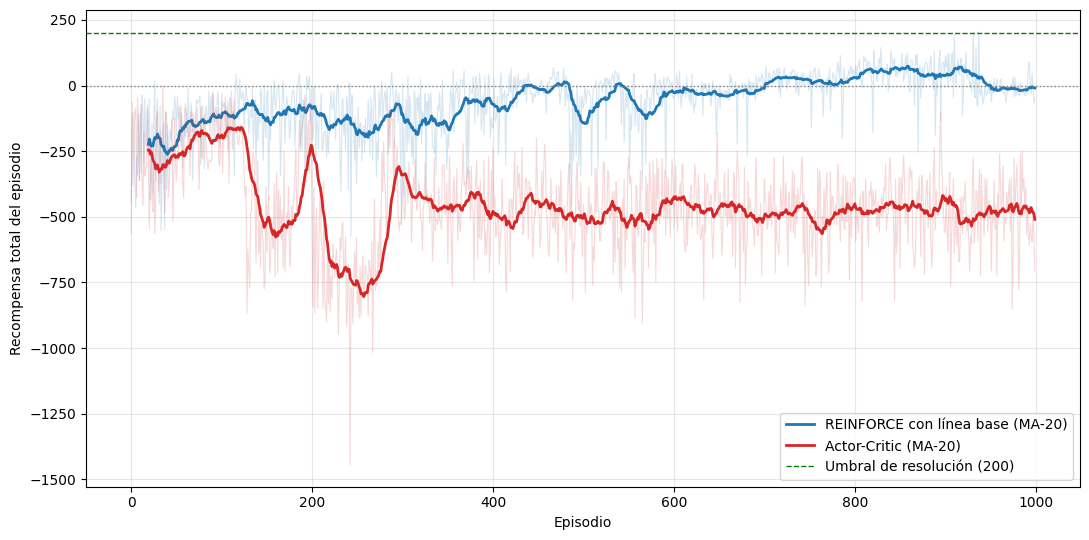

In [11]:
WINDOW = 20

plt.figure(figsize=(11, 5.5))
for h, label, color in [(hist_reinforce, "REINFORCE con línea base", "tab:blue"),
                        (hist_ac, "Actor-Critic", "tab:red")]:
    plt.plot(h["reward"], color=color, alpha=0.18, linewidth=0.8)
    x, ma = moving_average(h["reward"], WINDOW)
    plt.plot(x, ma, color=color, linewidth=2.0, label=f"{label} (MA-{WINDOW})")

plt.axhline(200, color="green", linestyle="--", linewidth=1, label="Umbral de resolución (200)")
plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Episodio")
plt.ylabel("Recompensa total del episodio")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

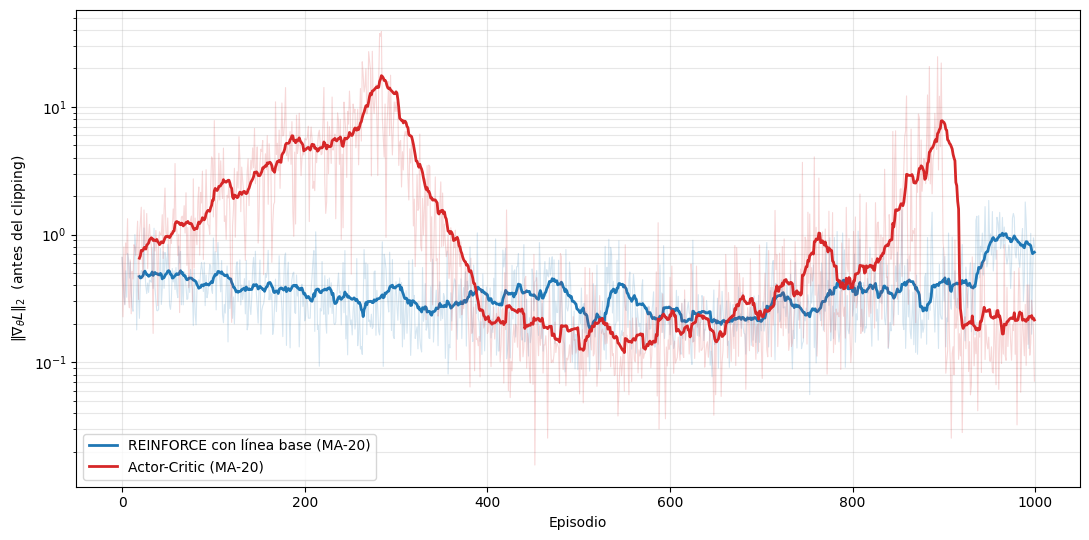

In [12]:
plt.figure(figsize=(11, 5.5))
for h, label, color in [(hist_reinforce, "REINFORCE con línea base", "tab:blue"),
                        (hist_ac, "Actor-Critic", "tab:red")]:
    plt.plot(h["grad_norm"], color=color, alpha=0.18, linewidth=0.8)
    x, ma = moving_average(h["grad_norm"], WINDOW)
    plt.plot(x, ma, color=color, linewidth=2.0, label=f"{label} (MA-{WINDOW})")

plt.yscale("log")
plt.xlabel("Episodio")
plt.ylabel(r"$\|\nabla_\theta L\|_2$  (antes del clipping)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

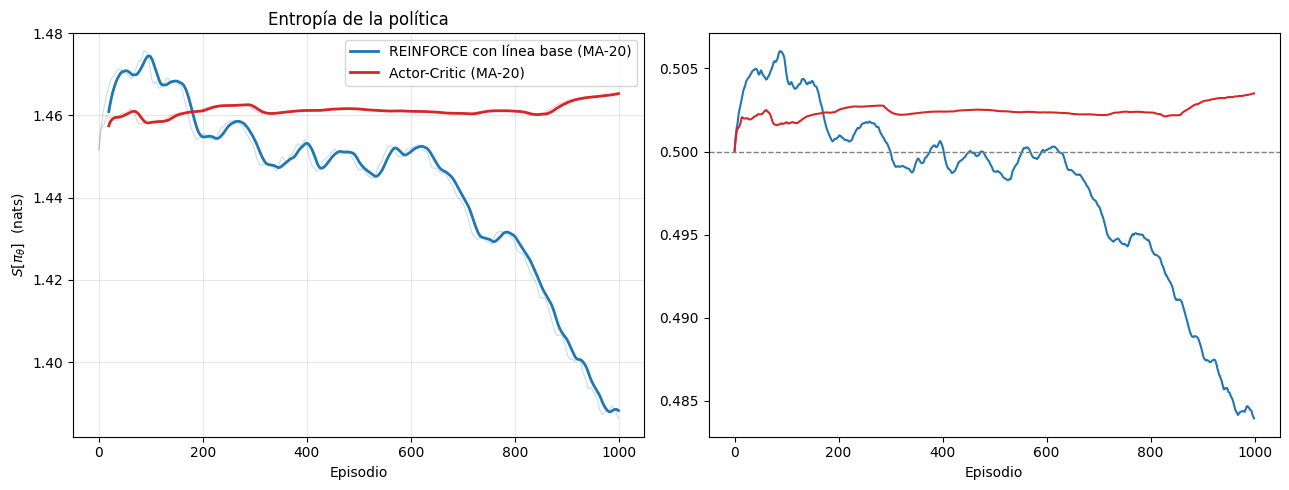

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for h, label, color in [(hist_reinforce, "REINFORCE con línea base", "tab:blue"),
                        (hist_ac, "Actor-Critic", "tab:red")]:
    axes[0].plot(h["entropy"], color=color, alpha=0.25, linewidth=0.8)
    x, ma = moving_average(h["entropy"], WINDOW)
    axes[0].plot(x, ma, color=color, linewidth=2.0, label=f"{label} (MA-{WINDOW})")

axes[0].set_xlabel("Episodio")
axes[0].set_ylabel(r"$S[\pi_\theta]$  (nats)")
axes[0].set_title("Entropía de la política")
axes[0].legend()
axes[0].grid(alpha=0.3)

const = 0.5 * math.log(2 * math.pi * math.e) * ACT_DIM
for h, label, color in [(hist_reinforce, "REINFORCE con línea base", "tab:blue"),
                        (hist_ac, "Actor-Critic", "tab:red")]:
    sigma_eq = np.exp((np.array(h["entropy"]) - const) / ACT_DIM)
    axes[1].plot(sigma_eq, color=color, linewidth=1.5, label=label)

axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1, label=r"$\sigma_0 = 0.5$")
axes[1].set_xlabel("Episodio")
plt.tight_layout()
plt.show()

In [14]:

def deterministic_action(net, obs):
    with torch.no_grad():
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
        out = net(obs_t)
        mu = out[0]
    return np.clip(mu.cpu().numpy(), ACT_LOW, ACT_HIGH)


def record_episode(net, seed=SEED, max_steps=1000):
    env, _ = make_env(render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames, total = [], 0.0
    for _ in range(max_steps):
        frames.append(env.render())
        obs, r, terminated, truncated, _ = env.step(deterministic_action(net, obs))
        total += r
        if terminated or truncated:
            break
    frames.append(env.render())
    env.close()
    return frames, total


def show_animation(frames, title, interval=40):
    fig = plt.figure(figsize=(5, 3.5))
    plt.axis("off")
    plt.title(title)
    img = plt.imshow(frames[0])
    def update(i):
        img.set_data(frames[i])
        return (img,)
    ani = animation.FuncAnimation(fig, update, frames=len(frames),
                                  interval=interval, blit=True)
    plt.close(fig)
    return ani


def show_strip(frames, title, n=6):
    idx = np.linspace(0, len(frames) - 1, n).astype(int)
    fig, axes = plt.subplots(1, n, figsize=(3 * n // 1.6, 3))
    for ax, i in zip(axes, idx):
        ax.imshow(frames[i])
        ax.set_title(f"t = {i}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

Actor-Critic — recompensa del episodio de evaluación: -822.59 (81 pasos)


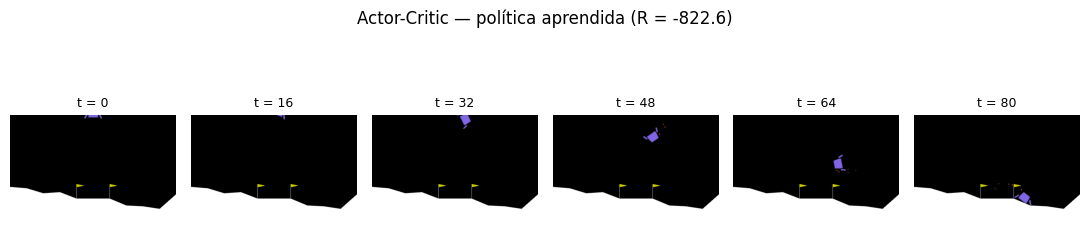

In [15]:
frames_ac, ret_ac = record_episode(ac_net, seed=SEED)
print(f"Actor-Critic — recompensa del episodio de evaluación: {ret_ac:.2f} "
      f"({len(frames_ac)} pasos)")

show_strip(frames_ac, f"Actor-Critic — política aprendida (R = {ret_ac:.1f})")
ani_ac = show_animation(frames_ac, f"Actor-Critic (R = {ret_ac:.1f})")
display(HTML(ani_ac.to_jshtml()))

c:\Users\rebe1\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment LunarLanderContinuous-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


REINFORCE+baseline — recompensa del episodio de evaluación: 192.17 (256 pasos)


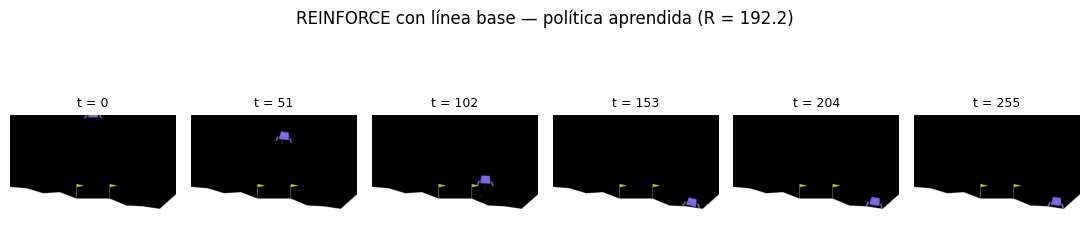

In [16]:
frames_rf, ret_rf = record_episode(actor_r, seed=SEED)
print(f"REINFORCE+baseline — recompensa del episodio de evaluación: {ret_rf:.2f} "
      f"({len(frames_rf)} pasos)")

show_strip(frames_rf, f"REINFORCE con línea base — política aprendida (R = {ret_rf:.1f})")
ani_rf = show_animation(frames_rf, f"REINFORCE con línea base (R = {ret_rf:.1f})")
display(HTML(ani_rf.to_jshtml()))

In [ ]:
def summarize(name, h):
    r = np.array(h["reward"])
    return {
        "algoritmo": name,
        "R medio (todos)": r.mean(),
        "R medio (últimos 100)": r[-100:].mean(),
        "R máximo": r.max(),
        "episodios con R > 200": int((r > 200).sum()),
        "||grad|| medio": np.mean(h["grad_norm"]),
        "S[pi] inicial": h["entropy"][0],
        "S[pi] final": h["entropy"][-1],
        "long. media episodio": np.mean(h["length"]),
    }


rows = [summarize("REINFORCE + línea base", hist_reinforce),
        summarize("Actor-Critic", hist_ac)]

keys = list(rows[0].keys())[1:]
print(f"{'métrica':<26} | {'REINFORCE+base':>16} | {'Actor-Critic':>16}")
print("-" * 66)
for k in keys:
    print(f"{k:<26} | {rows[0][k]:>16.3f} | {rows[1][k]:>16.3f}")

np.savez("resultados_rl.npz",
         reinforce_reward=hist_reinforce["reward"],
         reinforce_gradnorm=hist_reinforce["grad_norm"],
         reinforce_entropy=hist_reinforce["entropy"],
         ac_reward=hist_ac["reward"],
         ac_gradnorm=hist_ac["grad_norm"],
         ac_entropy=hist_ac["entropy"])
torch.save(actor_r.state_dict(), "reinforce_actor.pt")
torch.save(ac_net.state_dict(), "actor_critic.pt")

métrica                    |   REINFORCE+base |     Actor-Critic
------------------------------------------------------------------
R medio (todos)            |          -55.989 |         -458.239
R medio (últimos 100)      |           10.847 |         -492.781
R máximo                   |          205.268 |           -1.199
episodios con R > 200      |            1.000 |            0.000
||grad|| medio             |            0.373 |            1.965
S[pi] inicial              |            1.452 |            1.452
S[pi] final                |            1.386 |            1.466
long. media episodio       |          554.738 |           82.111

Resultados y pesos guardados.


## **Task 3 (Entrega Final)**

**1. Contrasten cada predicción de la Tarea 1 con los resultados observados. Para cada predicción indiquen si fue confirmada, refutada o inconclusa.**

**Predicción sobre Q-Learning/DQN vs. espacio de acción continuo (Pregunta 1).**
Esta predicción es de naturaleza teórica y no se implementó ni Q-Learning tabular ni DQN en la Tarea 2, por lo que no puede contrastarse directamente con datos. La consideramos **inconclusa por diseño**: el hecho de que ambos algoritmos de gradiente de política sí lograran entrenarse sobre `LunarLanderContinuous-v3` (dim(acción) = 2, continua) es consistente con el argumento de que un método basado en `argmax` sobre acciones discretas no era la ruta adecuada, pero no constituye una prueba empírica directa porque nunca se corrió el contraejemplo.

**Predicción sobre el gradiente analítico de la Gaussiana (Pregunta 2).**
**Confirmada.** La expresión $\nabla_\theta \ln \pi_\theta(A_t\mid S_t) = \frac{1}{\sigma^2}(A_t-\mu_\theta(S_t))\cdot\nabla_\theta\mu_\theta(S_t)$ es exactamente lo que PyTorch calcula internamente al hacer `dist.log_prob(actions_t).sum(-1)` seguido de `.backward()` sobre `Normal(mu, std)`. La evidencia indirecta de que el cálculo es correcto es que **REINFORCE efectivamente aprendió**: la recompensa promedio pasó de entornos de aterrizajes muy negativos ($R\approx-223$ en el episodio 50) a positivos y cercanos al umbral de resolución ($R\approx 205$ máximo, $10.85$ de promedio en los últimos 100 episodios), lo cual solo es posible si el gradiente del log-likelihood empuja correctamente $\mu_\theta$ hacia las acciones que produjeron retornos por encima de la línea base.

**Predicción de que Actor-Critic convergería más rápido que REINFORCE con línea base (Pregunta 3).**
**Refutada, y de forma contundente.** Ocurrió lo contrario de lo previsto:

| Métrica | REINFORCE + línea base | Actor-Critic |
|---|---|---|
| R medio (últimos 100 episodios) | **10.85** | **-492.78** |
| R máximo | **205.27** | -1.20 |
| Episodios con R > 200 | 1 | 0 |
| Longitud media del episodio | 554.7 pasos | 82.1 pasos |

En vez de converger más rápido, Actor-Critic **colapsó**: tras un breve período inicial comparable a REINFORCE, su recompensa se desplomó alrededor del episodio 150-300 y nunca se recuperó, terminando el entrenamiento con un desempeño peor que el que tenía al inicio. La longitud de episodio (82 pasos en promedio, contra 555 de REINFORCE) confirma que la política aprendida hace que la nave se estrelle casi de inmediato en lugar de sostener el vuelo.

La discrepancia es más informativa que una confirmación habría sido, y tiene una explicación concreta ligada a los supuestos que hicimos en la Tarea 1: predijimos que el sesgo introducido por $\hat V_w$ sería tolerable porque "el Crítico eventualmente converge". En la implementación real, el Actor y el Crítico **comparten el mismo cuerpo de red** (`ActorCriticNet`), de modo que los gradientes de la pérdida de valor y los de la política compiten dentro de los mismos pesos compartidos; además, al no usar un target network ni un buffer de repetición, el objetivo de bootstrapping $R_{t+1}+\gamma \hat V_w(S_{t+1})$ es un blanco que se mueve con cada actualización. Cuando el Crítico está mal calibrado en las primeras decenas de episodios (como es inevitable), produce estimaciones de ventaja con sesgo grande y erráticas; al usarse en cada paso (en vez de una vez por episodio como en REINFORCE), ese sesgo se inyecta de forma mucho más frecuente en el Actor. El resultado, visible en la sección 2, es un pico de norma de gradiente muy por encima de lo que REINFORCE experimenta, que empuja a la política a una región mucho peor del espacio de parámetros de la cual el algoritmo, al no tener ningún mecanismo de *trust region*, no logra escapar

**Predicción sobre incorporar suavidad de acciones para el exoesqueleto (Pregunta 4).**
**Inconclusa.** `LunarLanderContinuous-v3` no penaliza cambios bruscos entre acciones consecutivas y la Tarea 2 no implementó el término $r'_t = r_t-\lambda\lVert a_t-a_{t-1}\rVert^2$ ni ninguna de las modificaciones de arquitectura propuestas (acción previa como entrada, incrementos acotados, recurrencia). La predicción de que esto reforzaría la preferencia por Actor-Critic (por su señal densa por paso) sigue siendo razonable en el papel, pero no fue puesta a prueba con los experimentos realizados; de hecho, dado que en esta implementación concreta fue Actor-Critic el que colapsó, extender el entorno con una señal densa adicional sin antes resolver la inestabilidad observada en la sección 2 probablemente empeoraría, no mejoraría, su desempeño relativo.

**2. La norma ∥∇θL∥ durante el entrenamiento es un indicador de estabilidad. Describan su evolución para ambos algoritmos. ¿Hay episodios donde la norma es anormalmente alta? ¿Coinciden con caídas en la recompensa? ¿Qué implicación tiene eso sobre el problema de los pasos grandes que motivó PPO?**

**REINFORCE con línea base** mantiene una norma de gradiente baja y notablemente estable durante casi todo el entrenamiento, oscilando en su mayor parte entre 0.1 y 0.5 (ver gráfica de la sección de resultados, escala logarítmica). Solo hacia el final (episodios ~900-1000) se observa un incremento moderado hasta ~1-2, que coincide con la fase en la que la política empieza a descubrir la estrategia de aterrizaje exitosa (recompensa subiendo de valores negativos a positivos): es un aumento de gradiente "sano", producido por retornos Monte Carlo más informativos, no por inestabilidad.

**Actor-Critic**, en cambio, muestra una norma de gradiente mucho más alta y volátil desde el inicio. Se observa un pico muy pronunciado entre los episodios ~200 y ~300, donde la norma promedio (móvil) llega a superar 15-17, es decir, más de un orden de magnitud por encima de los valores típicos de REINFORCE en ese mismo rango de episodios. Existe un segundo pico, algo menor, alrededor de los episodios 750-900 (hasta ~8).

**Sí, estos picos coinciden exactamente con caídas de recompensa.** Comparando ambas gráficas: el colapso de la recompensa de Actor-Critic (de aproximadamente -200 a -700, en la gráfica de recompensas) ocurre en el mismo rango de episodios (~150-300) en el que la norma de gradiente se dispara. Esto no es casualidad: una actualización con una norma de gradiente anormalmente grande implica un paso igualmente grande en el espacio de parámetros $\theta$; si ese paso está mal orientado —como es probable cuando lo produce una estimación de ventaja sesgada por un Crítico aún no convergido—, la política puede saltar a una región de peor desempeño de la cual, en ausencia de restricciones sobre el tamaño del paso, no hay garantía de recuperación. De hecho, tras el pico, la recompensa de Actor-Critic nunca vuelve a acercarse a sus valores iniciales.

**Implicación para el problema de los pasos grandes que motivó PPO:** este resultado es precisamente la ilustración empírica del defecto que PPO fue diseñado para corregir. En el gradiente de política "vainilla" (y en Actor-Critic sin restricciones), el tamaño del paso de actualización depende de la magnitud de $\hat A_t$ y del learning rate, sin ningún control sobre cuánto se permite que $\pi_\theta$ se aleje de $\pi_{\theta_{\text{old}}}$ en una sola actualización. Cuando la estimación de ventaja es ruidosa o está sesgada (como ocurre aquí por el bootstrapping temprano del Crítico), un solo episodio puede producir un gradiente enorme que destruye en un paso el progreso acumulado durante cientos de episodios anteriores —exactamente lo que se observa en la gráfica de recompensa de Actor-Critic. PPO ataca este problema recortando el *ratio* de probabilidades $r_t(\theta)=\pi_\theta(a_t|s_t)/\pi_{\theta_{\text{old}}}(a_t|s_t)$ dentro de $[1-\epsilon, 1+\epsilon]$ en su objetivo sustituto, de modo que, sin importar qué tan grande o sesgada sea la ventaja estimada, la actualización de una sola iteración no puede mover la política más allá de una región de confianza acotada. El experimento con Actor-Critic muestra en la práctica por qué esa restricción es necesaria: sin ella, un episodio con una estimación de ventaja mala puede colapsar irreversiblemente el entrenamiento, tal como ocurrió aquí.

**3. La entropía de la política debería decrecer gradualmente durante el entrenamiento a medida que la política se vuelve más determinista. ¿Observan ese comportamiento? ¿En qué punto del entrenamiento la entropía cae más rápido? ¿Qué consecuencia tendría agregar un término de entropía en la pérdida como hace PPO?**

**En REINFORCE con línea base sí se observa el comportamiento esperado, aunque con retraso.** La entropía $S[\pi_\theta]$ se mantiene prácticamente plana (incluso sube ligeramente, de 1.452 a ~1.47) durante los primeros ~150-200 episodios, mientras la política todavía explora sin una señal de aprendizaje muy definida. A partir de ahí comienza a decrecer de forma gradual, y **la caída más pronunciada ocurre en el último tercio del entrenamiento, aproximadamente entre los episodios 700 y 1000**, donde $S[\pi_\theta]$ pasa de ~1.43 a su valor final de 1.386 ($\sigma$ efectivo bajando de 0.5 a ~0.48). Este tramo coincide exactamente con el período en que la recompensa de REINFORCE mejora más (de valores negativos a positivos, acercándose al umbral de 200): es el comportamiento esperado por la teoría, la política se vuelve más determinista (concentra su densidad alrededor de $\mu_\theta$) justo cuando empieza a encontrar acciones consistentemente buenas y ya no necesita explorar tan ampliamente.

**En Actor-Critic no se observa ese comportamiento.** Su entropía se mantiene esencialmente constante alrededor de 1.46 durante las 1000 episodios (con $\sigma\approx 0.502$-$0.504$ prácticamente invariable), e incluso termina ligeramente más alta que al inicio (1.452 → 1.466). Esto es consistente con el resto de los resultados: dado que la recompensa de Actor-Critic nunca mejora (de hecho empeora), el algoritmo nunca recibe una señal consistente de que ciertas acciones sean sistemáticamente mejores que otras, por lo que no tiene motivo para reducir su varianza de exploración. La entropía estancada es, en este caso, un síntoma más del colapso de aprendizaje descrito en la sección 2, no una propiedad distinta.

**Consecuencia de agregar un término de entropía a la pérdida, como hace PPO** ($L = L^{\text{CLIP}} - c_1 L^{V} + c_2 S[\pi_\theta]$, penalizando la pérdida de entropía): su función es mantener artificialmente un piso de exploración durante más tiempo, evitando que la política colapse a una varianza muy baja de forma prematura antes de haber explorado lo suficiente el espacio de acciones —un riesgo real cuando, como en REINFORCE aquí, la entropía cae bruscamente en una ventana relativamente corta del entrenamiento (episodios 700-1000). En nuestro caso, la caída de entropía de REINFORCE parece ser consecuencia de una mejora genuina en el desempeño, no un colapso prematuro, así que un bono de entropía probablemente solo retrasaría ligeramente la convergencia sin cambiar la conclusión, pero constituiría una salvaguarda razonable si el entrenamiento continuara más allá de 1000 episodios. Para el caso de Actor-Critic, un término de entropía **no ataca la causa raíz** del colapso —que es la inestabilidad del gradiente y el sesgo del Crítico documentados en la sección 2— por lo que no bastaría por sí solo para arreglarlo; sin embargo, es justamente la combinación de ese término de entropía **junto con** el recorte del objetivo sustituto (sección 2) lo que hace que PPO sea más robusto que un Actor-Critic sin restricciones: uno evita colapsos de un solo paso demasiado grande, y el otro evita que la política se vuelva determinista demasiado rápido antes de haber aprendido lo suficiente.


**Referencias**

- Hausknecht, M., & Stone, P. (2015). Deep recurrent Q-learning for partially observable MDPs. *AAAI Fall Symposium Series*. https://arxiv.org/abs/1507.06527
- Lillicrap, T. P., Hunt, J. J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D., & Wierstra, D. (2015). Continuous control with deep reinforcement learning. *arXiv preprint*. https://arxiv.org/abs/1509.02971
- Mysore, S., Mabsout, B., Mancuso, R., & Saenko, K. (2021). Regularizing action policies for smooth control with reinforcement learning. *2021 IEEE International Conference on Robotics and Automation (ICRA)*. https://arxiv.org/abs/2012.06644